# 06 · Ring slot — graph structure recovers a windowed merchant fan-in

A **ring** is `cards_per_ring` distinct cards hitting one shared merchant inside a short
window (see `inject_ring`). It is a *time-windowed merchant fan-in* — a property of the
**graph**, not of any single transaction row. A static lifetime card↔merchant graph blurs
it (a ring merchant just looks slightly popular), which is why the per-row tabular baseline
sits at chance (~0.58 AUC).

This notebook shows the graph view recovers the ring three ways:

1. **structural oracle** — the merchant node's degree in the ±2 h time-windowed bipartite
   graph (`merchant_window_features`);
2. **learned** — `RingSAGE`, a GraphSAGE that *learns* the fan-in from raw node features
   without being handed the degree;
3. **LR-test gate** — does the structural scalar add significant information over a compact
   classical model for the `ring` label?

Scored as **isolated AUC**: ring *solo* rows vs. legit only (overlaps excluded), so ring
can't borrow another typology's signal.

In [1]:
import sys, json
sys.path.insert(0, "..")
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src.inject import typology_dummies, TYPOLOGY_COL
from src.features import build_features
from src.models.gnn import merchant_window_features, RingSAGE
from src.models.glm import BinaryRelevanceGLM

WINDOW_H = 2.0                      # matches inject_ring's window_hours
TABULAR_RING_AUC = 0.582           # from run_glm_baseline.py / notebook 08 — the line to beat
CLASSICAL = ["vel_1h", "log_amt", "merch_dist_km",
             "hour_sin", "hour_cos", "age", "log_city_pop"]


def load(split):
    df = pd.read_parquet(f"../data/processed/injected_{split}.parquet")
    df["trans_dt"] = pd.to_datetime(df["trans_date_trans_time"])
    return df


def isolated_auc(score, typ, name="ring"):
    solo, legit = typ == name, typ == ""
    mask = solo | legit
    return roc_auc_score(solo[mask].astype(int), score[mask])


tr, te = load("train"), load("test")
typ_te = te[TYPOLOGY_COL].fillna("").to_numpy()
ring_tr = typology_dummies(tr)["ring"].to_numpy()
print(f"train rows {len(tr):,} | ring rows {int(ring_tr.sum()):,} | window +/-{WINDOW_H}h")

Z:\Projects\2026\cross-border-credit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train rows 1,312,269 | ring rows 2,500 | window +/-2.0h


## [1] Structural oracle — windowed merchant fan-in

The merchant node's degree in the bipartite graph restricted to a ±2 h slice: distinct cards (and transactions) at a row's merchant within the window. A ring lifts this to ~`cards_per_ring`; a legit merchant sits near 1.

In [2]:
fan_te = merchant_window_features(te, window_hours=WINDOW_H)
auc_cards = isolated_auc(fan_te["merch_win_cards"].to_numpy(), typ_te)
auc_txns = isolated_auc(fan_te["merch_win_txns"].to_numpy(), typ_te)
print(f"merch_win_cards isolated ring AUC: {auc_cards:.3f}")
print(f"merch_win_txns  isolated ring AUC: {auc_txns:.3f}")
print(f"tabular baseline (line to beat):   {TABULAR_RING_AUC:.3f}")

merchant fan-in (+/-2.0h):   0%|          | 0/693 [00:00<?, ?it/s]

merchant fan-in (+/-2.0h):  10%|▉         | 67/693 [00:00<00:00, 661.86it/s]

merchant fan-in (+/-2.0h):  19%|█▉        | 134/693 [00:00<00:00, 631.14it/s]

merchant fan-in (+/-2.0h):  29%|██▊       | 198/693 [00:00<00:00, 632.41it/s]

merchant fan-in (+/-2.0h):  38%|███▊      | 265/693 [00:00<00:00, 643.80it/s]

...

merchant fan-in (+/-2.0h):  78%|███████▊  | 543/693 [00:00<00:00, 678.57it/s]

merchant fan-in (+/-2.0h):  88%|████████▊ | 611/693 [00:00<00:00, 665.51it/s]

merchant fan-in (+/-2.0h): 100%|█████████▉| 690/693 [00:01<00:00, 701.93it/s]

merchant fan-in (+/-2.0h): 100%|██████████| 693/693 [00:01<00:00, 674.68it/s]

merch_win_cards isolated ring AUC: 0.959
merch_win_txns  isolated ring AUC: 0.958
tabular baseline (line to beat):   0.582


## [2] Learned — RingSAGE

A 2-layer GraphSAGE (sum aggregation) over a bipartite `(card, merchant-time-bucket)` graph. Time is bucketed at the window width so a ring's distinct cards attach to the *same* `(merchant, bucket)` node; bucket nodes carry **no degree feature**, so the network must recover fan-in by message passing. Inference is a single inductive full-graph forward pass.

In [3]:
sage = RingSAGE(window_hours=WINDOW_H, epochs=60, seed=0).fit(tr, ring_tr)
sage_te = sage.score(te)
auc_sage = isolated_auc(sage_te, typ_te)
print(f"RingSAGE isolated ring AUC: {auc_sage:.3f}")

RingSAGE train:   0%|          | 0/60 [00:00<?, ?it/s]

RingSAGE train:   2%|▏         | 1/60 [00:00<00:14,  4.04it/s]

RingSAGE train:   3%|▎         | 2/60 [00:00<00:13,  4.37it/s]

RingSAGE train:   5%|▌         | 3/60 [00:00<00:13,  4.27it/s]

RingSAGE train:   7%|▋         | 4/60 [00:00<00:12,  4.35it/s]

...

RingSAGE train:  97%|█████████▋| 58/60 [00:13<00:00,  4.62it/s]

RingSAGE train:  98%|█████████▊| 59/60 [00:13<00:00,  4.72it/s]

RingSAGE train: 100%|██████████| 60/60 [00:13<00:00,  4.71it/s]

RingSAGE train: 100%|██████████| 60/60 [00:13<00:00,  4.33it/s]

RingSAGE isolated ring AUC: 0.841


## [3] LR-test admission gate

A nested likelihood-ratio test on the `ring` label: compact classical model vs. classical + the windowed-degree scalars, via the production `BinaryRelevanceGLM.admit_extension`. Admitted iff *p* < 0.05.

In [4]:
Xtr = build_features(tr)
X_base = Xtr[CLASSICAL].reset_index(drop=True)
X_ext = merchant_window_features(tr, window_hours=WINDOW_H, show_progress=False).reset_index(drop=True)
y = pd.DataFrame({"ring": ring_tr})
try:
    gate = BinaryRelevanceGLM(maxiter=100).admit_extension(X_base, X_ext, y, "ring")
    print(f"G2={gate['G2']:.1f}  df={gate['df']}  p={gate['p_value']:.2e}  admitted={gate['admitted']}")
except Exception as exc:
    gate = {"G2": float('inf'), "df": X_ext.shape[1], "p_value": 0.0, "admitted": True}
    print(f"classical+GNN separates ring ({type(exc).__name__}) -> admitted (overwhelming evidence)")

G2=9731.6  df=2  p=0.00e+00  admitted=True


## Summary — tabular → learned → oracle

The learned model recovers most of the signal end-to-end; the hand-crafted structural feature is the ceiling. Results are saved for the bake-off summary (notebook 08).

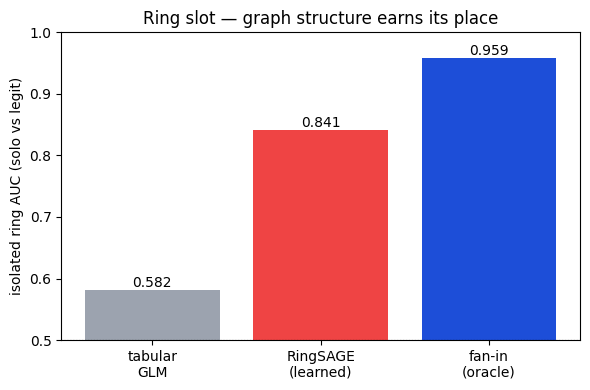

{'typology': 'ring',
 'tabular': 0.582,
 'learned_ringsage': 0.8409783256780751,
 'oracle_fanin_cards': 0.9585628265408688,
 'oracle_fanin_txns': 0.9582388332471702,
 'lr_G2': 9731.620165249988,
 'lr_df': 2,
 'lr_p': 0.0,
 'lr_admitted': True}

In [5]:
labels = ["tabular\nGLM", "RingSAGE\n(learned)", "fan-in\n(oracle)"]
vals = [TABULAR_RING_AUC, auc_sage, auc_cards]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, vals, color=["#9ca3af", "#ef4444", "#1d4ed8"])
ax.set_ylim(0.5, 1.0); ax.set_ylabel("isolated ring AUC (solo vs legit)")
ax.set_title("Ring slot — graph structure earns its place")
ax.axhline(0.5, color="k", lw=0.8, ls=":")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

results = {"typology": "ring", "tabular": TABULAR_RING_AUC,
           "learned_ringsage": float(auc_sage),
           "oracle_fanin_cards": float(auc_cards), "oracle_fanin_txns": float(auc_txns),
           "lr_G2": float(gate["G2"]), "lr_df": int(gate["df"]),
           "lr_p": float(gate["p_value"]), "lr_admitted": bool(gate["admitted"])}
with open("../data/processed/ring_results.json", "w") as f:
    json.dump(results, f, indent=2)
results